# データ読込

In [1]:
# ローカルユーティリティ: 外部ディレクトリ(utils, logic)への依存を排除
import pandas as pd
import sqlite3
from datetime import datetime, date, timedelta
from typing import Union, List
import jpholiday

# 日本の祝日取得（jpholiday が無ければ空集合）
def get_japanese_holidays(
    start: Union[str, date], end: Union[str, date], as_str: bool = True
) -> Union[List[str], List[date]]:
    """
    指定した期間の日本の祝日を取得する関数。

    Args:
        start (str or date): 開始日（"YYYY-MM-DD" または date型）
        end (str or date): 終了日（"YYYY-MM-DD" または date型）
        as_str (bool): Trueなら"YYYY-MM-DD"形式、Falseならdate型

    Returns:
        Union[List[str], List[date]]: 祝日のリスト（文字列またはdate型）
    """
    # --- 日付型でなければ変換 ---
    if isinstance(start, str):
        start = datetime.strptime(start, "%Y-%m-%d").date()
    if isinstance(end, str):
        end = datetime.strptime(end, "%Y-%m-%d").date()

    # --- 日付範囲の祝日抽出 ---
    holidays = [
        d
        for d in (start + timedelta(days=i) for i in range((end - start).days + 1))
        if jpholiday.is_holiday(d)
    ]

    return [d.strftime("%Y-%m-%d") for d in holidays] if as_str else holidays

# 日本語フォント設定（存在する最初の候補を適用）
def set_jp_font():
    try:
        import matplotlib.pyplot as plt
        from matplotlib import font_manager
        candidates = ["IPAexGothic", "IPAGothic", "Noto Sans CJK JP", "TakaoGothic"]
        system_fonts = font_manager.findSystemFonts()
        for cand in candidates:
            for f in system_fonts:
                if cand in f:
                    plt.rcParams["font.family"] = cand
                    return
    except Exception:
        pass  # フォント設定失敗は無視

# SQLite から重量データを読む（テーブル名は推測。存在するテーブルに合わせて変更可）
def load_data_from_sqlite(db_path="/work/app/data/factory_manage/weight_data.db", table_name="weight_data"):
    with sqlite3.connect(db_path) as conn:
        # テーブル存在チェック & 自動選択
        try:
            df_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
            if table_name not in df_tables['name'].tolist() and len(df_tables):
                # 最初のテーブルを利用
                table_name_local = df_tables['name'].iloc[0]
            else:
                table_name_local = table_name
        except Exception:
            table_name_local = table_name
        df_local = pd.read_sql(f"SELECT * FROM {table_name_local}", conn)
    # 日付カラム推測
    for col in ["伝票日付", "date", "dt"]:
        if col in df_local.columns:
            try:
                df_local[col] = pd.to_datetime(df_local[col])
            except Exception:
                pass
    return df_local

set_jp_font()
print("[INFO] ローカルユーティリティを読み込みました。")

# モジュールキャッシュのクリア（new_model1/new_model2 が部分的に読み込まれている場合に対応）
import sys, importlib
for name in list(sys.modules.keys()):
    if name.startswith('new_model1') or name.startswith('new_model2'):
        del sys.modules[name]
# 足りなければ /works/scripts を先頭に追加してからロード
sys.path.insert(0, '/works/scripts')
try:
    import new_model1
    importlib.reload(new_model1)
    print('reloaded new_model1 from', getattr(new_model1, '__file__', None))
except Exception as e:
    print('reload new_model1 failed:', e)
try:
    import new_model2
    importlib.reload(new_model2)
    print('reloaded new_model2 from', getattr(new_model2, '__file__', None))
except Exception as e:
    print('reload new_model2 failed:', e)

[INFO] ローカルユーティリティを読み込みました。
reloaded new_model1 from /works/scripts/new_model1/__init__.py
reloaded new_model2 from /works/scripts/new_model2/__init__.py
reloaded new_model1 from /works/scripts/new_model1/__init__.py
reloaded new_model2 from /works/scripts/new_model2/__init__.py


In [3]:
import pandas as pd
# from logic.factory_manage.utils.sql import load_data_from_sqlite  # 外部依存 -> ローカル版へ
# from utils.get_holydays import get_japanese_holidays             # 外部依存 -> ローカル版へ

# from utils.font import set_jp_font  # 外部フォント設定 -> ローカル版
# set_jp_font()  # 既に前セルで実行済み

# CSV / DB 読み込み（パスはPRE_HANNNYU配下に限定）
# path = "/works/data/factory_manage/weight_data.db"  # そのまま利用

# df = load_data_from_sqlite(path)
# df["伝票日付"].max()
# df.head()

### 2021年～

In [4]:
# pdは既にCELL INDEX:1でimportされているので、そのまま使えます
df_2021 = pd.read_csv("/works/data/input/2020顧客.csv", encoding="utf-8")
df_2022 = pd.read_csv("/works/data/input/2022顧客.csv", encoding="utf-8")
df_2023 = pd.read_csv("/works/data/input/2023_all.csv", encoding="utf-8")
df_2024 = pd.read_csv("/works/data/input/20240501-20250422.csv", encoding="utf-8")

df_2021 = df_2021[['伝票日付', '商品', '正味重量']]
df_2022 = df_2022[['伝票日付', '商品', '正味重量']]
df_2023 = df_2023[['伝票日付', '商品', '正味重量']]
df_2021.rename(columns={'商品': '品名'}, inplace=True)
df_2022.rename(columns={'商品': '品名'}, inplace=True)
df_2023.rename(columns={'商品': '品名'}, inplace=True)
df_2024 = df_2024[['伝票日付', '品名', '正味重量']]

df_all = pd.concat([df_2021, df_2022, df_2023, df_2024], ignore_index=True)
# 曜日など () を削除
df_all["伝票日付"] = df_all["伝票日付"].str.replace(r"\(.*\)", "", regex=True)
df_all["伝票日付"] = pd.to_datetime(df_all["伝票日付"], format="%Y/%m/%d")
# --- 型変換: 正味重量 ---
df_all["正味重量"] = pd.to_numeric(df_all["正味重量"], errors="coerce")
df_all = df_all.dropna(subset=["正味重量"]).copy()
df_all


/tmp/ipykernel_51004/2848577853.py:4: DtypeWarning: Columns (68) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("/works/data/input/2023_all.csv", encoding="utf-8")
/tmp/ipykernel_51004/2848577853.py:5: DtypeWarning: Columns (9,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2024 = pd.read_csv("/works/data/input/20240501-20250422.csv", encoding="utf-8")


,伝票日付,品名,正味重量
0,2020-01-04,混合廃棄物A,870.0
1,2020-01-04,混合廃棄物A,450.0
2,2020-01-04,混合廃棄物（焼却物）,2400.0
3,2020-01-04,混合廃棄物A,250.0
4,2020-01-04,混合廃棄物A,800.0
...,...,...,...
199525,2025-08-31,木くず,1440.0
199526,2025-08-31,選別,1060.0
199527,2025-08-31,選別,1820.0
199528,2025-08-31,GC 軽鉄･ｽﾁｰﾙ類,440.0


In [ ]:
# --- LightGBMデバッグ用: 特徴量・目的変数の分布・ユニーク数・サンプル数を確認 ---
def debug_lgbm_input(X, y, prefix=""):
    print(f"{prefix}X describe:\n", X.describe())
    print(f"{prefix}X nunique:\n", X.nunique())
    print(f"{prefix}y describe:\n", y.describe())
    print(f"{prefix}サンプル数: {len(X)}")

# 例: 学習前にfoldごとに呼び出す
# debug_lgbm_input(X_train, y_train, prefix="[FOLD1]")


### 予約情報

In [5]:
df_reserve = pd.read_csv(
    "/works/data/input/yoyaku_data.csv")
# --- 型変換: 予約台数 ---
df_reserve["予約日"] = pd.to_datetime(df_reserve["予約日"])
df_reserve.rename(columns={"台数": "予約台数"}, inplace=True)
df_reserve["予約台数"] = pd.to_numeric(df_reserve["予約台数"], errors="coerce")
df_reserve = df_reserve.dropna(subset=["予約台数"]).copy()
print(df_reserve["予約日"].min(), df_reserve["予約日"].max())
print(df_reserve.columns)
df_reserve

2023-01-04 00:00:00 2025-08-31 00:00:00
Index(['予約日', '予約得意先名', '固定客', '予約台数'], dtype='object')


,予約日,予約得意先名,固定客,予約台数
0,2023-01-04,アンデス,False,1
1,2023-01-04,リサイクルレスキュー,False,1
2,2023-01-04,山口興業,False,2
3,2023-01-04,明和建装,False,1
4,2023-01-04,まごころ清掃社,False,1
...,...,...,...,...
50230,2025-08-31,フロンティア,True,3
50231,2025-08-31,まごのて,True,3
50232,2025-08-31,谷津商会,True,1
50233,2025-08-31,友進,True,1


### 受入番号用

In [6]:
import os
import glob
import pandas as pd

# ディレクトリ内の全CSVファイルパスを取得
csv_dir = "/works/data/input/受入_時刻"
csv_files = glob.glob(os.path.join(csv_dir, "*.csv"))

# 全CSVを読み込んで結合
dfs = []
for f in csv_files:
    df_tmp = pd.read_csv(f)

    # 伝票日付を整形 → 日付型へ変換
    df_tmp["伝票日付"] = df_tmp["伝票日付"].str.replace(r"\(.*?\)", "", regex=True).str.strip()
    df_tmp["伝票日付"] = pd.to_datetime(df_tmp["伝票日付"], format="%Y/%m/%d")

    # 正味重量をカンマ除去して数値化
    df_tmp["正味重量"] = pd.to_numeric(df_tmp["正味重量"].replace({',': ''}, regex=True), errors="coerce")
    df_tmp = df_tmp.dropna(subset=["正味重量"]).copy()

    # 受入番号の欠損を埋めて型変換（念のため）
    df_tmp["受入番号"] = df_tmp["受入番号"].fillna(-1).astype(int)

    dfs.append(df_tmp)

df_Ukeire = pd.concat(dfs, ignore_index=True)

# 必要カラムだけ抽出（品名・重量・受入番号）
df_Ukeire = df_Ukeire[["伝票日付", "品名", "正味重量", "受入番号"]].copy()
# --- 型変換: 念のため再度 ---
df_Ukeire["正味重量"] = pd.to_numeric(df_Ukeire["正味重量"], errors="coerce")
df_Ukeire = df_Ukeire.dropna(subset=["正味重量"]).copy()

# 台数カウント準備（日付・品名ごとの受入番号ユニーク数）
df_count = (
    df_Ukeire.groupby(["伝票日付", "品名"])["受入番号"]
    .nunique()
    .reset_index()
    .rename(columns={"受入番号": "台数"})
)

# （参考）結合しておく場合
df_merged = pd.merge(df_Ukeire, df_count, on=["伝票日付", "品名"], how="left")

# リネーム
df_merged.rename(columns={"台数": "搬入済台数"}, inplace=True)
# --- 型変換: 搬入済台数 ---
df_merged["搬入済台数"] = pd.to_numeric(df_merged["搬入済台数"], errors="coerce")
df_merged = df_merged.dropna(subset=["搬入済台数"]).copy()

# 結果確認
df_merged


,伝票日付,品名,正味重量,受入番号,搬入済台数
0,2024-12-01,混合廃棄物A,1100.0,31839,25
1,2024-12-01,混合廃棄物A,720.0,31851,25
2,2024-12-01,混合廃棄物A,1860.0,31834,25
3,2024-12-01,混合廃棄物A,1060.0,31874,25
4,2024-12-01,混合廃棄物B,100.0,31840,3
...,...,...,...,...,...
58994,2025-03-31,混合廃棄物A,170.0,46735,68
58995,2025-03-31,選別,80.0,46735,13
58996,2025-03-31,GC 軽鉄･ｽﾁｰﾙ類,160.0,46735,9
58997,2025-03-31,金属くず,400.0,46656,1


In [7]:
target_items = ["混合廃棄物A", "混合廃棄物B", "GC 軽鉄･ｽﾁｰﾙ類", "選別", "木くず"]

# 成功・モデル

## 予約数の追加モデル

In [8]:
# new_model1: PRE_HANNNYU/scripts/new_model1 内のローカルモジュールを動的パス追加で利用

import sys, os
SCRIPT_ROOT = "/works/scripts"
if SCRIPT_ROOT not in sys.path:
    sys.path.append(SCRIPT_ROOT)

# robust import

from new_model1 import full_walkforward, ReserveFeatureBuilder


import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt


In [9]:

# default: do not run full heavy pipeline unless explicitly enabled
RUN_PIPELINE = True

# 閾値（暫定的に緩和して予測生成が行われるか確認）
MIN_STAGE1_DAYS = 20  # 元:30
MIN_STAGE2_DAYS = 10  # 元:15

if RUN_PIPELINE:
    # 予約特徴量生成
    df_reserve_feat = ReserveFeatureBuilder(df_reserve).build()

    # 対象日を予約日に限定 (学習データが足りない場合はこのフィルタを緩めることを検討)
    reserve_dates = df_reserve_feat.index
    df_all["伝票日付"] = pd.to_datetime(df_all["伝票日付"])
    df_all = df_all[df_all["伝票日付"].isin(reserve_dates)].copy()

    print("[DEBUG] reservation_filtered_days=", df_all["伝票日付"].nunique())
    print("[DEBUG] reservation_span=", df_all["伝票日付"].min(), "->", df_all["伝票日付"].max())

    # 評価日数
    days_list = [300]
    results = []
    for days in days_list:
        print(f"\n=== {days}日分のデータで評価中 ===")
        latest_date = df_all["伝票日付"].max()
        cutoff_date = latest_date - pd.Timedelta(days=days)
        df_subset = df_all[df_all["伝票日付"] >= cutoff_date].copy()
        hol_max = df_subset["伝票日付"].max()
        hol_min = df_subset["伝票日付"].min()
        holidays = get_japanese_holidays(hol_min, hol_max)
        print("[DEBUG] df_subset_days=", df_subset["伝票日付"].nunique(), "range=", hol_min, "->", hol_max)
        try:
            actual, pred = full_walkforward(
                df_subset,
                holidays=holidays,
                df_reserve=df_reserve,
                min_stage1_days=MIN_STAGE1_DAYS,
                min_stage2_days=MIN_STAGE2_DAYS,
                top_n=2,
            )
            print(f"[DEBUG] returned_lengths actual={len(actual) if isinstance(actual, list) else 'NA'} pred={len(pred) if isinstance(pred, list) else 'NA'}")
            if isinstance(actual, list) and isinstance(pred, list) and len(actual) > 0 and len(pred) > 0:
                r2 = r2_score(actual, pred)
                mae = mean_absolute_error(actual, pred)
                results.append((days, r2, mae))
                print(f"✅ R² = {r2:.3f}, MAE = {mae:,.0f}kg")
            else:
                print("⚠ 評価に十分なデータがありません (予測件数0)")
                results.append((days, None, None))
        except Exception as e:
            print(f"❌ エラー: {e}")
            results.append((days, None, None))

    # 結果表示
    import pandas as pd

    df_result = pd.DataFrame(results, columns=["days", "R2", "MAE"])
    print("\n=== 評価結果 ===")
    print(df_result)
    if df_result["R2"].notna().any():
        plt.plot(df_result["days"], df_result["R2"], marker="o")
        plt.xlabel("Days")
        plt.ylabel("R² Score")
        plt.title("日数別 R² 評価 (new_model1)")
        plt.grid(True)
        plt.show()
else:
    print('Imports successful. To run pipeline, set RUN_PIPELINE = True in this cell.')


[DEBUG] ReserveFeatureBuilder.build: incoming columns=['予約日', '予約得意先名', '固定客', '予約台数']
[DEBUG] ReserveFeatureBuilder.build: sample rows=
{'予約日': [Timestamp('2023-01-04 00:00:00'), Timestamp('2023-01-04 00:00:00'), Timestamp('2023-01-04 00:00:00')], '予約得意先名': ['アンデス', 'リサイクルレスキュー', '山口興業'], '固定客': [False, False, False], '予約台数': [1, 1, 2]}
[DEBUG] reservation_filtered_days= 852
[DEBUG] reservation_span= 2023-01-04 00:00:00 -> 2025-08-31 00:00:00

=== 300日分のデータで評価中 ===
[DEBUG] df_subset_days= 279 range= 2024-11-04 00:00:00 -> 2025-08-31 00:00:00
▶️ full_walkforward 開始
[DEBUG] full_walkforward: df_raw.shape=(43525, 3), holidays_type=<class 'list'> df_reserve.shape=(50235, 4)
[DEBUG] WeightFeatureBuilder.build: past_raw.shape=(43525, 3), target_items=['混合廃棄物A', '混合廃棄物B']
[DEBUG] WeightFeatureBuilder.build: holidays type=<class 'list'>, len_or_none=15
[DEBUG] WeightFeatureBuilder.build: df_pivot.shape=(279, 134), df_feat.shape=(279, 17)
[DEBUG] ReserveFeatureBuilder.build: incoming columns=[

KeyboardInterrupt: 

## 天気追加モデル

[INFO] using WeatherFeatureBuilder from new_model2.feature_builder

=== 90日分のデータで評価中 (weather) ===
[DEBUG] hol_min, hol_max = 2025-06-02 00:00:00 2025-08-31 00:00:00
[DEBUG] reserve_raw_rows=4479 range=2025-06-02 00:00:00->2025-08-31 00:00:00
[Weather] fetch 2025-06-02 -> 2025-08-31
[Weather] final params start_date=2025-06-02 end_date=2025-08-31
[Weather] status=200 url=https://archive-api.open-meteo.com/v1/archive?latitude=35.6895&longitude=139.6917&start_date=2025-06-02&end_date=2025-08-31&daily=temperature_2m_mean&daily=precipitation_sum&timezone=Asia%2FTokyo
[Weather] rows=91 cols=['平均気温', '降水量', '天気_晴れ', '天気_雨', '天気_大雨', '天気_台風']
[DEBUG] weather_rows=91 range=2025-06-02 00:00:00->2025-08-31 00:00:00
▶️ full_walkforward(new_model2) 開始
[DEBUG] target_items=['混合廃棄物A', '混合廃棄物B']
[DEBUG] feature_list_len=23 df_feat_rows=74
[DEBUG] dates_len=74 min_stage1_days=30 min_stage2_days=15
[SKIP] 2025-06-13 (i=0) < min_stage1_days=30
[SKIP] 2025-06-18 (i=5) < min_stage1_days=30
[SKIP] 2025-06-

/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35413 (\N{CJK UNIFIED IDEOGRAPH-8A55}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  fig.canvas

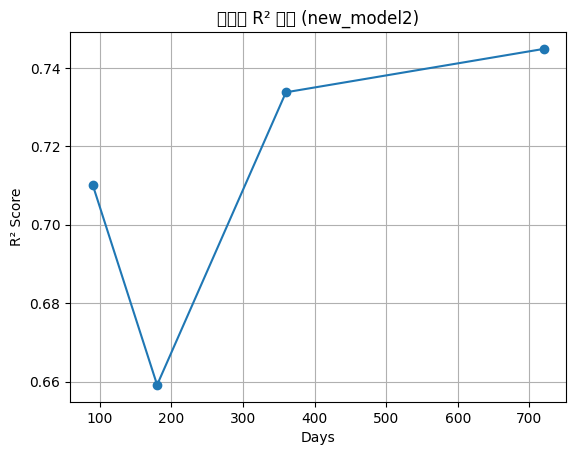

In [12]:
# new_model2: PRE_HANNNYU/scripts/new_model2 内のローカルモジュール利用 (再読込対応)
import sys, os, importlib
SCRIPT_ROOT = "/works/scripts"
if SCRIPT_ROOT not in sys.path:
    sys.path.append(SCRIPT_ROOT)
# 既存モジュールを再読込して最新パッチ反映
import new_model2.feature_builder as nm2_fb
import new_model2.predict_model_v4_2_4 as nm2_pred
importlib.reload(nm2_fb)
importlib.reload(nm2_pred)
from new_model2.predict_model_v4_2_4 import full_walkforward
from new_model2.feature_builder import WeatherFeatureBuilder, ReserveFeatureBuilder
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

print('[INFO] using WeatherFeatureBuilder from', WeatherFeatureBuilder.__module__)

# 予約 raw データは df_reserve として既に存在 (列: 予約日, 予約得意先名, 固定客, 予約台数)
# 集計済み特徴量はここでは不要なので生成しない（full_walkforward 内で再度 ReserveFeatureBuilder を用いるため）
if not pd.api.types.is_datetime64_any_dtype(df_reserve['予約日']):
    df_reserve['予約日'] = pd.to_datetime(df_reserve['予約日'])

# 日付型保証
if not pd.api.types.is_datetime64_any_dtype(df_all["伝票日付"]):
    df_all["伝票日付"] = pd.to_datetime(df_all["伝票日付"])

# 評価対象の日数リスト
days_list = [90,180,360,720]  # 検証を速くするため一旦 1 パターン
results = []

for days in days_list:
    print(f"\n=== {days}日分のデータで評価中 (weather) ===")
    latest_date = df_all["伝票日付"].max()
    cutoff_date = latest_date - pd.Timedelta(days=days)
    df_subset = df_all[df_all["伝票日付"] >= cutoff_date].copy()
    hol_min = df_subset["伝票日付"].min()
    hol_max = df_subset["伝票日付"].max()
    print('[DEBUG] hol_min, hol_max =', hol_min, hol_max)
    holidays = get_japanese_holidays(hol_min, hol_max)

    # 予約 raw サブセット（列 予約日 でフィルタ）
    mask = (df_reserve['予約日'] >= hol_min) & (df_reserve['予約日'] <= hol_max)
    df_reserve_raw_subset = df_reserve.loc[mask].copy()
    print(f"[DEBUG] reserve_raw_rows={len(df_reserve_raw_subset)} range={df_reserve_raw_subset['予約日'].min()}->{df_reserve_raw_subset['予約日'].max() if len(df_reserve_raw_subset) else 'NA'}")

    # 天気特徴量取得
    weather_builder = WeatherFeatureBuilder(start_date=hol_min, end_date=hol_max, enable_fallback=True)
    df_weather_full = weather_builder.build()
    df_weather = df_weather_full.loc[hol_min:hol_max].copy() if not df_weather_full.empty else df_weather_full
    if len(df_weather) > 0:
        print(f"[DEBUG] weather_rows={len(df_weather)} range={df_weather.index.min()}->{df_weather.index.max()}")
    else:
        print("[DEBUG] weather empty (fallback or no data)")

    try:
        actual, pred = full_walkforward(
            df_raw=df_subset,
            df_reserve=df_reserve_raw_subset,  # 修正: raw を渡す
            holidays=holidays,
            df_weather=df_weather,
            min_stage1_days=30,
            min_stage2_days=15,
            top_n=2,
        )
        print(f"[DEBUG] returned_lengths actual={len(actual) if isinstance(actual,list) else 'NA'} pred={len(pred) if isinstance(pred,list) else 'NA'}")
        if isinstance(actual, list) and isinstance(pred, list) and len(actual) > 0 and len(pred) > 0:
            r2 = r2_score(actual, pred)
            mae = mean_absolute_error(actual, pred)
            results.append((days, r2, mae))
            print(f"✅ R² = {r2:.3f}, MAE = {mae:,.0f}kg")
        else:
            print("⚠ 評価に十分なデータがありません (予測件数0)")
            results.append((days, None, None))
    except Exception as e:
        print(f"❌ エラー: {e}")
        results.append((days, None, None))

# 結果表示
import pandas as pd

df_result = pd.DataFrame(results, columns=["days", "R2", "MAE"])
print("\n=== 評価結果 (new_model2) ===")
print(df_result)
if df_result["R2"].notna().any():
    plt.plot(df_result["days"], df_result["R2"], marker="o")
    plt.xlabel("Days")
    plt.ylabel("R² Score")
    plt.title("日数別 R² 評価 (new_model2)")
    plt.grid(True)
    plt.show()
else:
    print("R² 有効値が無いためプロットをスキップ")

In [14]:
# --- new_model2 full_walkforward ステージ2（GradientBoostingRegressor）ハイパーパラメータ最適化 ---
from sklearn.model_selection import ParameterGrid
import new_model2.predict_model_v4_2_4 as nm2_pred
from new_model2.predict_model_v4_2_4 import full_walkforward
import numpy as np

# パラメータ空間（必要に応じて拡張可）
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.07],
    "max_depth": [3, 4, 5],
}

best_score = -np.inf
best_params = None

# ステージ2のtrain_and_predict_stage2をパッチ
original_train_and_predict_stage2 = nm2_pred.train_and_predict_stage2
from sklearn.ensemble import GradientBoostingRegressor

def make_stage2_with_params(params):
    def train_and_predict_stage2_patch(all_stage1_rows, stage1_results, df_feat_today, target_items):
        df_hist = pd.DataFrame(all_stage1_rows[:-1])
        X_train = df_hist.drop(columns=["合計"])
        y_train = df_hist["合計"]
        from sklearn.preprocessing import StandardScaler
        from sklearn.feature_selection import VarianceThreshold
        scaler = StandardScaler()
        selector = VarianceThreshold(1e-4)
        X_train_filtered = selector.fit_transform(scaler.fit_transform(X_train))
        gbdt = GradientBoostingRegressor(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            random_state=42
        )
        gbdt.fit(X_train_filtered, y_train)
        X_target = {f"{item}_予測": [stage1_results[f"{item}_予測"]] for item in target_items}
        for col in df_feat_today.columns:
            if col not in X_target:
                X_target[col] = df_feat_today.iloc[0][col]
        X_target = pd.DataFrame(X_target)
        total_pred = gbdt.predict(selector.transform(scaler.transform(X_target)))[0]
        return total_pred
    return train_and_predict_stage2_patch

for params in ParameterGrid(param_grid):
    nm2_pred.train_and_predict_stage2 = make_stage2_with_params(params)
    try:
        actual, pred = full_walkforward(
            df_raw=df_all,
            holidays=holidays,
            df_reserve=df_reserve,
            df_weather=df_weather,
            min_stage1_days=30,
            min_stage2_days=15,
            top_n=2,
        )
        if len(actual) > 0 and len(pred) > 0:
            r2 = r2_score(actual, pred)
            print(f"params={params} R2={r2:.4f}")
            if r2 > best_score:
                best_score = r2
                best_params = params
    except Exception as e:
        print(f"params={params} でエラー: {e}")

nm2_pred.train_and_predict_stage2 = original_train_and_predict_stage2

print("=== 最良パラメータ ===")
print(best_params)
print(f"R2={best_score:.4f}")

▶️ full_walkforward(new_model2) 開始
[DEBUG] target_items=['混合廃棄物A', '混合廃棄物B']
[DEBUG] feature_list_len=23 df_feat_rows=842
[DEBUG] dates_len=842 min_stage1_days=30 min_stage2_days=15
[SKIP] 2023-01-14 (i=0) < min_stage1_days=30
[SKIP] 2023-01-19 (i=5) < min_stage1_days=30
[SKIP] 2023-01-24 (i=10) < min_stage1_days=30
[SKIP] 2023-01-29 (i=15) < min_stage1_days=30
[SKIP] 2023-02-03 (i=20) < min_stage1_days=30
[SKIP] 2023-02-08 (i=25) < min_stage1_days=30

=== 2023-02-14 を予測中 (i=30) ===
[DEBUG] ステージ2未実行 rows=1/16

=== 2023-02-15 を予測中 (i=31) ===
[DEBUG] feature_list_len=23 df_feat_rows=842
[DEBUG] dates_len=842 min_stage1_days=30 min_stage2_days=15
[SKIP] 2023-01-14 (i=0) < min_stage1_days=30
[SKIP] 2023-01-19 (i=5) < min_stage1_days=30
[SKIP] 2023-01-24 (i=10) < min_stage1_days=30
[SKIP] 2023-01-29 (i=15) < min_stage1_days=30
[SKIP] 2023-02-03 (i=20) < min_stage1_days=30
[SKIP] 2023-02-08 (i=25) < min_stage1_days=30

=== 2023-02-14 を予測中 (i=30) ===
[DEBUG] ステージ2未実行 rows=1/16

=== 2023-02-15

KeyboardInterrupt: 

In [18]:
# デバッグ: hol_min / hol_max の型確認用一時セル
print('sample hol_min/hol_max (from df_all tail)')
print(df_all['伝票日付'].tail(1), type(df_all['伝票日付'].iloc[-1]))

sample hol_min/hol_max (from df_all tail)
184249   2025-05-26
Name: 伝票日付, dtype: datetime64[ns] <class 'pandas._libs.tslibs.timestamps.Timestamp'>


## Kaggleスタイルのブレンディング/スタッキング概要

- 目的: 時系列(1日先)のwalkforward評価で、Kaggleでも定番の「複数GBDT(LightGBM/XGBoost/CatBoost)を組み合わせる」手法を導入します。
- 構成:
  - ベースモデル: LightGBM, XGBoost, CatBoost（すべて回帰）。
  - ブレンド1: 等重み平均（シンプルで強いKaggle定番）。
  - ブレンド2: OOFメタ特徴に対するRidge回帰スタッキング（リーク防止のため、学習期間内でTimeSeriesSplitによりOOFを作成）。
- 評価: walkforward（過去で学習→翌日を予測）でR²とMAE。
- 注意:
  - 特徴量は日次ターゲット(y)、カレンダー、祝日、ラグ/移動平均、予約の集計を使用。
  - 内部OOFは各学習期間でTimeSeriesSplitを用い、リークを防止します。
  - 実行時間短縮のため、評価対象期間(EVAL_DAYS_SPAN)と各モデルの木数(iterations/estimators)は控えめに設定しています。必要に応じて増やしてください。

In [25]:
# Kaggle定番: GBDT 3種のブレンド/OOFスタックによるwalkforward評価
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge

# Boosterライブラリ
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

# 1) 日次ターゲット生成（df_allから日次合計）
_df = df_all.copy()
_df_day = (
    _df.groupby(_df["伝票日付"].dt.date)["正味重量"].sum()
    .rename("y").to_frame()
)
_df_day.index = pd.to_datetime(_df_day.index)

# 2) カレンダー・ラグ特徴
cal = pd.DataFrame(index=pd.date_range(_df_day.index.min(), _df_day.index.max(), freq="D"))
cal.index.name = "date"
cal["dow"] = cal.index.dayofweek
cal["is_month_start"] = (cal.index.day == 1).astype(int)
cal["is_month_end"] = (cal.index + pd.offsets.Day(1)).day == 1
cal["is_month_end"] = cal["is_month_end"].astype(int)

# 祝日
hol = set(get_japanese_holidays(cal.index.min().date(), cal.index.max().date(), as_str=True))
cal["is_holiday"] = cal.index.strftime("%Y-%m-%d").isin(hol).astype(int)

# ラグ/移動平均（最小限）
def add_lags(df, col, lags=(1,7,14), mas=(7,14)):
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)
    for W in mas:
        df[f"{col}_ma{W}"] = df[col].rolling(W).mean()
    return df

feat = cal.join(_df_day, how="left").fillna(0)
feat = add_lags(feat, "y")
feat = feat.dropna().copy()

# 3) 予約集計特徴（簡易: 日次合計台数/固定客比率）
res = df_reserve.copy()
res["予約日"] = pd.to_datetime(res["予約日"]).dt.date
res_day = res.groupby("予約日").agg(
    reserve_count=("予約日", "size"),
    reserve_sum=("予約台数", "sum"),
    fixed_ratio=("固定客", lambda s: np.mean((s == 1) | (s == True) | (s == "1")))
)
res_day.index = pd.to_datetime(res_day.index)
feat = feat.join(res_day, how="left").fillna(0)

# 特徴/目的
y_all = feat["y"].copy()
X_all = feat.drop(columns=["y"]).copy()

# 4) walkforward設定（軽量化）
EVAL_DAYS_SPAN = 180  # ← 初回は短く
MIN_TRAIN_DAYS = 120  # ← 学習最少日数を少し緩め

all_dates = X_all.index
end_eval = all_dates.max()
start_eval = end_eval - pd.Timedelta(days=EVAL_DAYS_SPAN)

pred_records = []

# 5) 各日ループ: 過去で学習→翌日予測
for pred_day in pd.date_range(start_eval, end_eval, freq="D"):
    train_mask = all_dates < pred_day
    if (train_mask.sum() < MIN_TRAIN_DAYS):
        continue
    X_tr, y_tr = X_all.loc[train_mask], y_all.loc[train_mask]
    X_te = X_all.loc[[pred_day]] if pred_day in X_all.index else None
    if X_te is None or len(X_te) == 0:
        continue

    # 5-1) ベース3モデル学習（軽量パラメータ）
    lgbm = lgb.LGBMRegressor(
        n_estimators=120,
        num_leaves=48,
        learning_rate=0.07,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
    )
    xgbr = xgb.XGBRegressor(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.07,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    cat = CatBoostRegressor(
        iterations=150,
        depth=6,
        learning_rate=0.07,
        loss_function="MAE",
        random_seed=42,
        verbose=False
    )

    lgbm.fit(X_tr, y_tr)
    xgbr.fit(X_tr, y_tr)
    cat.fit(X_tr, y_tr)

    p_lgb = lgbm.predict(X_te)[0]
    p_xgb = xgbr.predict(X_te)[0]
    p_cat = cat.predict(X_te)[0]

    # 5-2) 等重みブレンド
    p_blend = np.mean([p_lgb, p_xgb, p_cat])

    # 5-3) OOFスタッキング（学習期間内でTimeSeriesSplit）
    meta_pred = None
    try:
        tscv = TimeSeriesSplit(n_splits=4)
        oof = np.zeros((len(X_tr), 3))
        for i, (tr_idx, va_idx) in enumerate(tscv.split(X_tr)):
            X_tr_i, X_va_i = X_tr.iloc[tr_idx], X_tr.iloc[va_idx]
            y_tr_i, y_va_i = y_tr.iloc[tr_idx], y_tr.iloc[va_idx]
            l_i = lgb.LGBMRegressor(n_estimators=80, num_leaves=32, learning_rate=0.08, random_state=42)
            x_i = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1, tree_method="hist")
            c_i = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.08, loss_function="MAE", random_seed=42, verbose=False)
            l_i.fit(X_tr_i, y_tr_i)
            x_i.fit(X_tr_i, y_tr_i)
            c_i.fit(X_tr_i, y_tr_i)
            oof[va_idx, 0] = l_i.predict(X_va_i)
            oof[va_idx, 1] = x_i.predict(X_va_i)
            oof[va_idx, 2] = c_i.predict(X_va_i)
        meta = Ridge(alpha=1.0)
        meta.fit(oof, y_tr.values)
        base_te = np.array([[p_lgb, p_xgb, p_cat]])
        meta_pred = float(meta.predict(base_te)[0])
    except Exception as e:
        meta_pred = None

    y_true = float(y_all.loc[pred_day])
    pred_records.append({
        "date": pred_day,
        "y_true": y_true,
        "lgb": float(p_lgb),
        "xgb": float(p_xgb),
        "cat": float(p_cat),
        "blend_eq": float(p_blend),
        "stack_ridge": float(meta_pred) if meta_pred is not None else None,
    })

RES = pd.DataFrame(pred_records).set_index("date")
# スコア
if len(RES):
    for col in ["lgb", "xgb", "cat", "blend_eq", "stack_ridge"]:
        if col in RES and RES[col].notna().any():
            r2 = r2_score(RES["y_true"], RES[col].fillna(method="ffill"))
            mae = mean_absolute_error(RES["y_true"], RES[col].fillna(method="ffill"))
            print(f"{col:12s}  R2={r2: .3f}  MAE={mae:,.0f}kg")
else:
    print("予測件数がゼロでした。EVAL_DAYS_SPAN/MIN_TRAIN_DAYS等を見直してください。")

RES.tail(10)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1649
[LightGBM] [Info] Number of data points in the train set: 1872, number of used features: 12
[LightGBM] [Info] Start training from score 62857.264957
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 588
[LightGBM] [Info] Number of data points in the train set: 376, number of used features: 6
[LightGBM] [Info] Start training from score 109580.372340
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

/tmp/ipykernel_726/3393452187.py:161: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  r2 = r2_score(RES["y_true"], RES[col].fillna(method="ffill"))
/tmp/ipykernel_726/3393452187.py:162: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  mae = mean_absolute_error(RES["y_true"], RES[col].fillna(method="ffill"))
/tmp/ipykernel_726/3393452187.py:161: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  r2 = r2_score(RES["y_true"], RES[col].fillna(method="ffill"))
/tmp/ipykernel_726/3393452187.py:162: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  mae = mean_absolute_error(RES["y_true"], RES[col].fillna(method="ffill"))
/tmp/ipykernel_726/3393452187.py:161

,y_true,lgb,xgb,cat,blend_eq,stack_ridge
date,,,,,,
2025-08-22,105910.0,100891.430680,100022.328125,102397.539477,101103.766094,101423.114673
2025-08-23,81620.0,102446.702052,97513.093750,93323.378967,97761.058257,98649.617551
2025-08-24,28420.0,37241.912783,41431.593750,43960.068363,40877.858298,60579.832034
2025-08-25,75170.0,69338.654724,90986.085938,90339.705060,83554.815240,84978.902693
2025-08-26,97280.0,90576.727172,100717.343750,96550.444109,95948.171677,94981.080865
2025-08-27,91500.0,94042.131519,93197.367188,94302.634009,93847.377572,95398.971216
2025-08-28,76730.0,93165.914388,90841.398438,94876.244218,92961.185681,95778.553044
2025-08-29,77200.0,83040.936682,86423.242188,90314.202251,86592.793707,89343.201190
2025-08-30,74900.0,82036.297738,84359.960938,83204.598640,83200.285772,88295.186005


### 使い方 / 高速実行のコツ

- 実行負荷を下げたい場合:
  - コード先頭の `EVAL_DAYS_SPAN = 360` を `180` に下げる。
  - `MIN_TRAIN_DAYS = 180` を `90` へ下げる（ただし精度は少し下がります）。
  - LGBM/XGB/Cat の `n_estimators` / `iterations` を 50–150 程度に下げる。
- 精度を上げたい場合:
  - `n_estimators` / `iterations` を増やす（500–1500）。
  - ラグ/移動平均を増やす（例: lag28, ma28, ma56 など）。
  - 予約特徴の拡充（固定客比率の他、予約台数の7日移動平均や曜日別予約強度など）。
- 次の強化案（任意）:
  - 既存の new_model2 の予測値を「第4のベース特徴」として meta へ入力（リーク防止のため、学習期間内でのOOF生成が必要）。

In [15]:
# === 最良パラメータ固定での短期再評価（new_model2 / Stage2 GBDT） ===
import sys, pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error
sys.path.insert(0, '/works/scripts')
import new_model2.predict_model_v4_2_4 as nm2_pred
from new_model2.predict_model_v4_2_4 import full_walkforward
from new_model2.feature_builder import WeatherFeatureBuilder

# 既知の最適パラメータ（ユーザー提供）
BEST_PARAMS = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
print('[RUN] Re-eval Stage2 GBDT with fixed BEST_PARAMS:', BEST_PARAMS)

# 評価対象期間（軽量）
DAYS = 360
df_all['伝票日付'] = pd.to_datetime(df_all['伝票日付'])
latest_date = df_all['伝票日付'].max()
cutoff_date = latest_date - pd.Timedelta(days=DAYS)
df_subset = df_all[df_all['伝票日付'] >= cutoff_date].copy()
hol_min, hol_max = df_subset['伝票日付'].min(), df_subset['伝票日付'].max()

# 祝日・天気を該当期間で準備
def _to_date(x):
    return x.date() if hasattr(x, 'date') else x
holidays_local = get_japanese_holidays(_to_date(hol_min), _to_date(hol_max))
wb = WeatherFeatureBuilder(start_date=hol_min, end_date=hol_max, enable_fallback=True)
df_weather_full = wb.build()
df_weather_local = df_weather_full.loc[hol_min:hol_max].copy() if not df_weather_full.empty else df_weather_full

# 予約 raw も期間内に絞る
df_reserve_local = df_reserve[(df_reserve['予約日'] >= hol_min) & (df_reserve['予約日'] <= hol_max)].copy()

# Stage2 パッチ（最良パラメータ適用）
original_train_and_predict_stage2 = nm2_pred.train_and_predict_stage2
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import GradientBoostingRegressor

def train_and_predict_stage2_best(all_stage1_rows, stage1_results, df_feat_today, target_items):
    df_hist = pd.DataFrame(all_stage1_rows[:-1])  # 直近1日はターゲット日特徴
    if df_hist.empty:
        return float(sum(stage1_results.get(f"{item}_予測", 0.0) for item in target_items))
    X_train = df_hist.drop(columns=['合計'])
    y_train = df_hist['合計']
    scaler = StandardScaler()
    selector = VarianceThreshold(1e-4)
    Xf = selector.fit_transform(scaler.fit_transform(X_train))
    gbdt = GradientBoostingRegressor(
        n_estimators=BEST_PARAMS['n_estimators'],
        learning_rate=BEST_PARAMS['learning_rate'],
        max_depth=BEST_PARAMS['max_depth'],
        random_state=42,
    )
    gbdt.fit(Xf, y_train)
    # 予測対象日の特徴を組み立て
    X_target = {f"{item}_予測": [stage1_results.get(f"{item}_予測", 0.0)] for item in target_items}
    for col in df_feat_today.columns:
        if col not in X_target:
            X_target[col] = df_feat_today.iloc[0][col]
    X_target = pd.DataFrame(X_target)
    yhat = gbdt.predict(selector.transform(scaler.transform(X_target)))[0]
    return float(yhat)

nm2_pred.train_and_predict_stage2 = train_and_predict_stage2_best
try:
    actual_b, pred_b = full_walkforward(
        df_raw=df_subset,
        df_reserve=df_reserve_local,
        holidays=holidays_local,
        df_weather=df_weather_local,
        min_stage1_days=30, min_stage2_days=15, top_n=2,
    )
    if isinstance(actual_b, list) and isinstance(pred_b, list) and len(actual_b)>0 and len(pred_b)>0:
        r2_b = r2_score(actual_b, pred_b)
        mae_b = mean_absolute_error(actual_b, pred_b)
        print(f'【再評価】DAYS={DAYS} R²={r2_b:.4f}  MAE={mae_b:,.0f}kg  (fixed best)')
    else:
        print('予測件数が0件のためスコア算出不可でした。期間/閾値を見直してください。')
except Exception as e:
    print('再評価中にエラー:', e)
finally:
    nm2_pred.train_and_predict_stage2 = original_train_and_predict_stage2

[RUN] Re-eval Stage2 GBDT with fixed BEST_PARAMS: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
[Weather] fetch 2024-09-05 -> 2025-08-31
[Weather] final params start_date=2024-09-05 end_date=2025-08-31
[Weather] status=200 url=https://archive-api.open-meteo.com/v1/archive?latitude=35.6895&longitude=139.6917&start_date=2024-09-05&end_date=2025-08-31&daily=temperature_2m_mean&daily=precipitation_sum&timezone=Asia%2FTokyo
[Weather] rows=361 cols=['平均気温', '降水量', '天気_大雨', '天気_晴れ', '天気_雨', '天気_台風']
▶️ full_walkforward(new_model2) 開始
[DEBUG] target_items=['混合廃棄物A', '混合廃棄物B']
[DEBUG] feature_list_len=23 df_feat_rows=327
[DEBUG] dates_len=327 min_stage1_days=30 min_stage2_days=15
[SKIP] 2024-09-16 (i=0) < min_stage1_days=30
[SKIP] 2024-09-21 (i=5) < min_stage1_days=30
[SKIP] 2024-09-26 (i=10) < min_stage1_days=30
[SKIP] 2024-10-01 (i=15) < min_stage1_days=30
[SKIP] 2024-10-06 (i=20) < min_stage1_days=30
[SKIP] 2024-10-11 (i=25) < min_stage1_days=30

=== 2024-10-17 を予測中 (i=30) ===